--- Datensatz Überblick ---
Anzahl Zeilen: 10000, Anzahl Spalten: 14



C:\Users\Moata\AppData\Local\Temp\ipykernel_63536\1082217311.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Machine failure', palette='Set1')


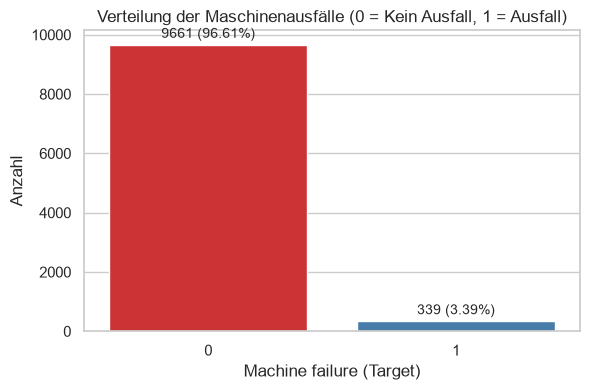

C:\Users\Moata\AppData\Local\Temp\ipykernel_63536\1082217311.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=failure_counts.values, y=failure_counts.index, palette='magma')


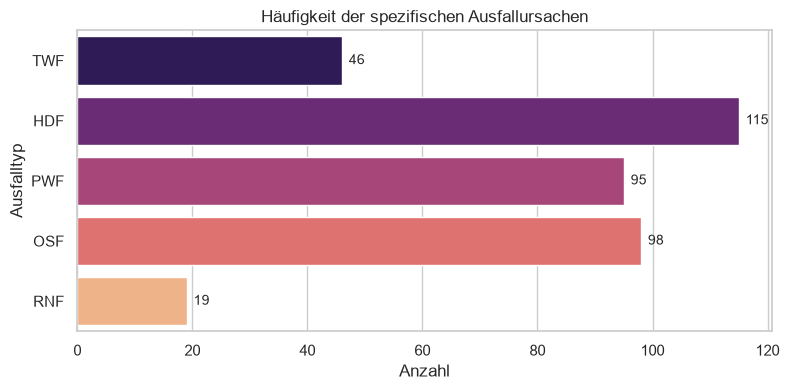

C:\Users\Moata\AppData\Local\Temp\ipykernel_63536\1082217311.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Machine failure', y=feature, ax=axes[i], palette='Set2')
C:\Users\Moata\AppData\Local\Temp\ipykernel_63536\1082217311.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Machine failure', y=feature, ax=axes[i], palette='Set2')
C:\Users\Moata\AppData\Local\Temp\ipykernel_63536\1082217311.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Machine failure', y=feature, ax=axes[i], palette='Set2'

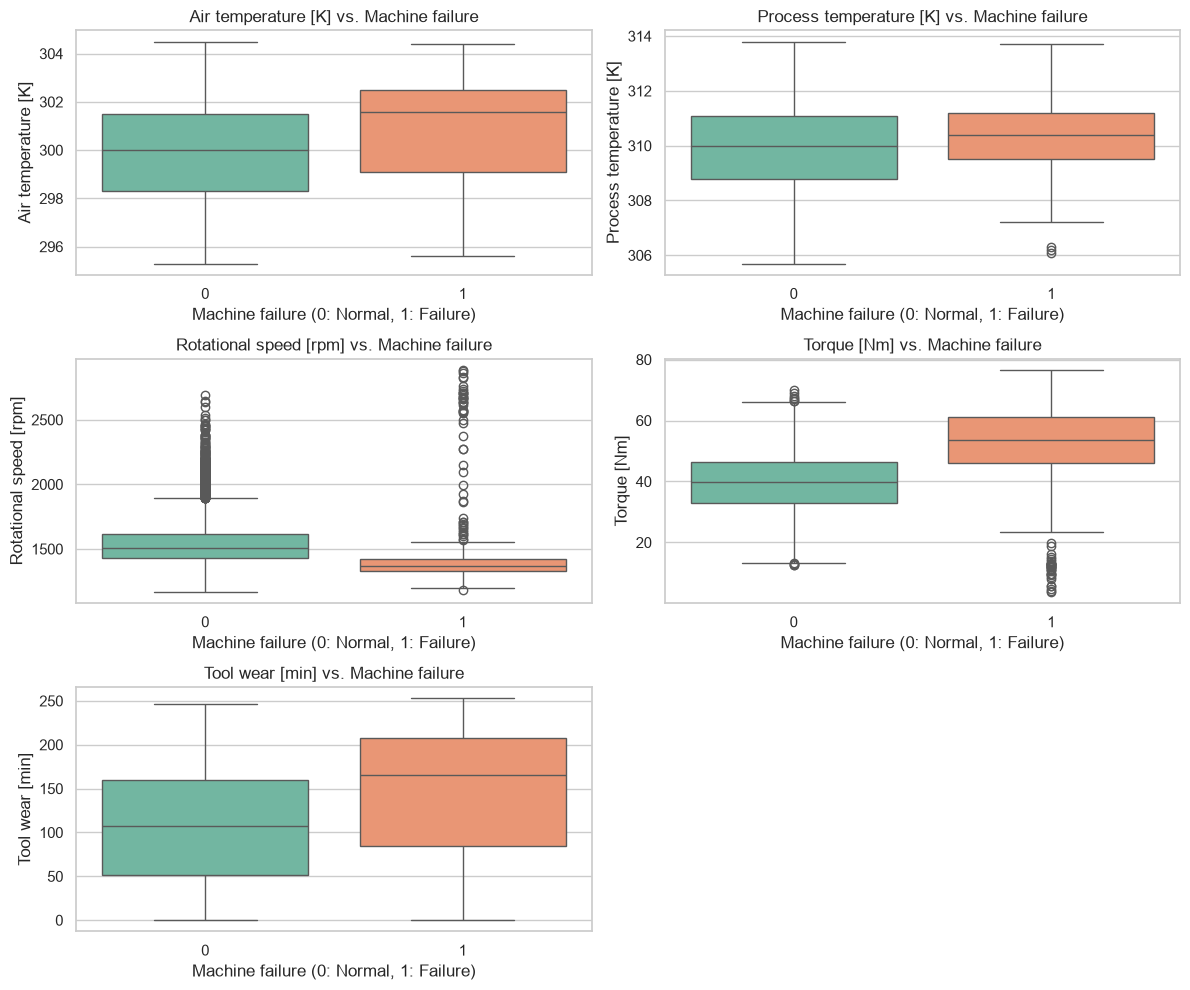

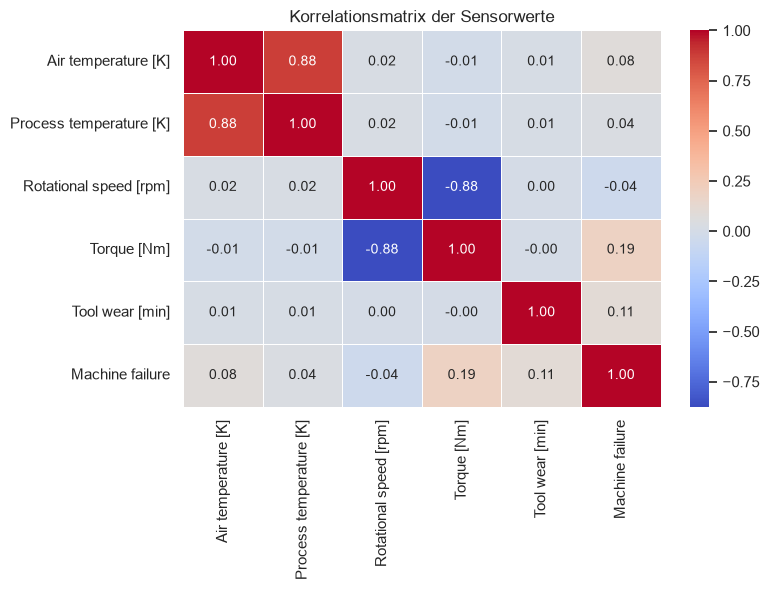

EDA abgeschlossen. Alle Grafiken wurden unter '../reports/' gespeichert.


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Zielordner 'reports' festlegen & automatisch erstellen
output_dir = '../reports' if os.path.exists('../reports') else 'reports'
os.makedirs(output_dir, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

# 1. Daten laden
data_path = '../data/raw/ai4i2020.csv' if os.path.exists('../data') else 'data/raw/ai4i2020.csv'
df = pd.read_csv(data_path)

print("--- Datensatz Überblick ---")
print(f"Anzahl Zeilen: {df.shape[0]}, Anzahl Spalten: {df.shape[1]}\n")

# 2. Verteilung der Zielvariable
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Machine failure', palette='Set1')
plt.title('Verteilung der Maschinenausfälle (0 = Kein Ausfall, 1 = Ausfall)')
plt.xlabel('Machine failure (Target)')
plt.ylabel('Anzahl')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    ax.annotate(f'{int(p.get_height())} ({percentage})', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'target_distribution.png'), dpi=300)
plt.show()

# 3. Ausfallursachen (TWF, HDF, PWF, OSF, RNF)
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df[failure_cols].sum()

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=failure_counts.values, y=failure_counts.index, palette='magma')
plt.title('Häufigkeit der spezifischen Ausfallursachen')
plt.xlabel('Anzahl')
plt.ylabel('Ausfalltyp')

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'failure_types.png'), dpi=300)
plt.show()

# 4. Sensor-Boxplots
sensor_features = [
    'Air temperature [K]', 
    'Process temperature [K]', 
    'Rotational speed [rpm]', 
    'Torque [Nm]', 
    'Tool wear [min]'
]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(sensor_features):
    sns.boxplot(data=df, x='Machine failure', y=feature, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature} vs. Machine failure')
    axes[i].set_xlabel('Machine failure (0: Normal, 1: Failure)')

fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'sensor_boxplots.png'), dpi=300)
plt.show()

# 5. Korrelationsmatrix
plt.figure(figsize=(8, 6))
numeric_df = df[sensor_features + ['Machine failure']]
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Korrelationsmatrix der Sensorwerte')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'sensor_correlation.png'), dpi=300)
plt.show()

print(f"EDA abgeschlossen. Alle Grafiken wurden unter '{output_dir}/' gespeichert.")